# 1.0-reservations-visitors-eda

In [50]:
import matplotlib.pyplot as plt
import pandas as pd
from recruit_restaurant_visitor_forecasting.config.config import (
    AIR_AREA_COL,
    AIR_GENRE_COL,
    AIR_RESTAURANT_ID_COL,
    CALENDAR_DATE_COL,
    HPG_AREA_COL,
    HPG_RESTAURANT_ID_COL,
    RESERVE_DATETIME_COL,
    RESERVE_VISITORS_COL,
    VISIT_DATE_COL,
    VISIT_DATETIME_COL,
    VISITORS_COL,
    RAW_DATA_DIR,
    RANDOM_SEED,
    HOLIDAY_COL
)
from recruit_restaurant_visitor_forecasting.config.features import (
    RESERVE_AIR_COL,
    RESERVE_HPG_COL,
    CITY_COL,
    CITY_REGION_COL,
    TOTAL_RES_COL,
    CITY_REGION_DIV_N,
    CITY_DIV_N,
    VISITORS_DIFF_COL,
    DAY_OF_WEEK_COL,
    RES_IMPOSSIBILITY_COL,
    OPEN_DATE_COL
)
from recruit_restaurant_visitor_forecasting.dataset import (
    fill_missing_dates,
    prepare_datetime_columns,
    split_reserve_by_date,
    standardize_date,
)
from recruit_restaurant_visitor_forecasting.features import (
    add_holiday_columns,
    get_first_str_values,
    fill_city_by_nearest,
    cluster_cities,
    add_reservation_impossibility,
    fill_air_res_gaps
)
from recruit_restaurant_visitor_forecasting.plots import (
    plot_pairs_rel,
    plot_over_reservation,
    plot_hpg_interc_pct
)
from recruit_restaurant_visitor_forecasting.utils import (
    get_first_dates,
    get_group_size_ratio,
    get_abs_reservation,
    get_all_zero_reservations
)
from recruit_restaurant_visitor_forecasting.config.preprocessing import EMPTY_DATES_RANGE
from recruit_restaurant_visitor_forecasting.eda import print_period_problematic_rest

## Df preparing

In [51]:
HPG_SUFFIX = "_hpg"
AIR_SUFFIX = "_air"

In [52]:
air_reserve_df = pd.read_csv(RAW_DATA_DIR / "air_reserve.csv")
air_store_df = pd.read_csv(RAW_DATA_DIR / "air_store_info.csv")
air_visit_df = pd.read_csv(RAW_DATA_DIR / "air_visit_data.csv")

hpg_reserve_df = pd.read_csv(RAW_DATA_DIR / "hpg_reserve.csv")
hpg_store_df = pd.read_csv(RAW_DATA_DIR / "hpg_store_info.csv")

date_info_df = pd.read_csv(RAW_DATA_DIR / "date_info.csv")
store_id_rel_df = pd.read_csv(RAW_DATA_DIR / "store_id_relation.csv")
sample_submission_df = pd.read_csv(RAW_DATA_DIR / "sample_submission.csv")

In [53]:
prepare_datetime_columns(air_reserve_df)
prepare_datetime_columns(hpg_reserve_df)

standardize_date(date_info_df, CALENDAR_DATE_COL)
standardize_date(air_visit_df, VISIT_DATE_COL)

sample_submission_df[[AIR_RESTAURANT_ID_COL, VISIT_DATE_COL]] = sample_submission_df[
    "id"
].str.rsplit("_", n=1, expand=True)
standardize_date(sample_submission_df, VISIT_DATE_COL)

In [54]:
hpg_reserve_df = hpg_reserve_df.merge(
    store_id_rel_df,
    on=HPG_RESTAURANT_ID_COL,
    how="left",
)

In [55]:
air_res_filled = fill_missing_dates(
    air_reserve_df,
    VISIT_DATE_COL,
    AIR_RESTAURANT_ID_COL,
    RESERVE_VISITORS_COL,
)
hpg_res_filled = fill_missing_dates(
    hpg_reserve_df,
    VISIT_DATE_COL,
    HPG_RESTAURANT_ID_COL,
    RESERVE_VISITORS_COL,
)

In [56]:
min_sample_date = sample_submission_df[VISIT_DATE_COL].min()
air_res_filled = fill_air_res_gaps(air_res_filled, hpg_res_filled, EMPTY_DATES_RANGE)

air_res_occurred_df, air_res_target_df = split_reserve_by_date(
    air_res_filled, min_sample_date, VISIT_DATE_COL
)

hpg_res_occurred_df, hpg_res_target_df = split_reserve_by_date(
    hpg_reserve_df, min_sample_date
)

In [57]:
air_store_df[CITY_REGION_COL] = get_first_str_values(air_store_df[AIR_AREA_COL], CITY_REGION_DIV_N)
air_store_df[CITY_COL] = get_first_str_values(air_store_df[AIR_AREA_COL], CITY_DIV_N)

hpg_store_df[CITY_REGION_COL] = get_first_str_values(hpg_store_df[HPG_AREA_COL], CITY_REGION_DIV_N)
hpg_store_df[CITY_COL] = get_first_str_values(hpg_store_df[HPG_AREA_COL], CITY_DIV_N)

In [58]:
GENRE_REPLACEMENTS = {
    "Asian": "Japanese food",
    "Okonomiyaki/Monja/Teppanyaki": "Japanese food",
    "International cuisine": "Western food",
    "Karaoke/Party": "Other",
}
air_store_df[AIR_GENRE_COL] = air_store_df[AIR_GENRE_COL].replace(GENRE_REPLACEMENTS)

In [59]:
best_k = 4
air_store_df = cluster_cities(air_store_df, best_k, RANDOM_SEED)

In [60]:
CITY_REPLACEMENTS = {
    "Osaka": "Ōsaka-fu",
    "Kanagawa-ken": "Tōkyō-to",
    "Saitama-ken": "Tōkyō-to",
}
hpg_store_df[CITY_COL] = hpg_store_df[CITY_COL].replace(CITY_REPLACEMENTS)
hpg_store_df = fill_city_by_nearest(hpg_store_df)
hpg_store_df = cluster_cities(hpg_store_df, best_k, RANDOM_SEED)

In [61]:
air_res_min = get_first_dates(air_res_filled, AIR_RESTAURANT_ID_COL)
air_visit_min = get_first_dates(air_visit_df, AIR_RESTAURANT_ID_COL)
hpg_air_min = get_first_dates(hpg_res_filled, AIR_RESTAURANT_ID_COL)

In [62]:
air_min = (
    pd.concat([air_res_min, air_visit_min, hpg_air_min], axis=1)
    .min(axis=1)
    .rename(VISIT_DATE_COL)
)

In [63]:
air_visit_full = fill_missing_dates(
    air_visit_df, VISIT_DATE_COL, AIR_RESTAURANT_ID_COL, VISITORS_COL, air_visit_min
)

In [64]:
air_visit_air_res = air_visit_full.merge(
    get_abs_reservation(air_res_occurred_df, AIR_RESTAURANT_ID_COL),
    on=[AIR_RESTAURANT_ID_COL, VISIT_DATE_COL],
    how="left",
).fillna(0)
air_visit_hpg_merged = pd.merge(
    air_visit_full, store_id_rel_df, on=AIR_RESTAURANT_ID_COL, how='inner'
)
hpg_res_air_merged = hpg_res_occurred_df[~hpg_res_occurred_df[AIR_RESTAURANT_ID_COL].isna()]
air_visit_hpg_res = air_visit_hpg_merged.merge(
    get_abs_reservation(hpg_res_air_merged, HPG_RESTAURANT_ID_COL),
    on=[HPG_RESTAURANT_ID_COL, VISIT_DATE_COL],
    how="left",
).fillna(0)

In [65]:
all_merged = pd.merge(
    air_visit_hpg_res,
    air_visit_air_res,
    on=[AIR_RESTAURANT_ID_COL, VISIT_DATE_COL, VISITORS_COL],
    how="outer",
    suffixes=(HPG_SUFFIX, AIR_SUFFIX),
).rename(columns={
    RESERVE_VISITORS_COL + HPG_SUFFIX: RESERVE_HPG_COL,
    RESERVE_VISITORS_COL + AIR_SUFFIX: RESERVE_AIR_COL,
}).fillna(0)

In [66]:
all_merged[TOTAL_RES_COL] = all_merged[RESERVE_HPG_COL] + all_merged[RESERVE_AIR_COL]
all_merged[VISITORS_DIFF_COL] = all_merged[TOTAL_RES_COL] - all_merged[VISITORS_COL]

In [67]:
air_hpg_genre_merged = store_id_rel_df.merge(
    air_store_df,
    on=[AIR_RESTAURANT_ID_COL],
    how="inner"
).merge(
    hpg_store_df,
    on=[HPG_RESTAURANT_ID_COL],
    how="inner"
)

In [68]:
air_open_dates = (
    air_visit_df.groupby(AIR_RESTAURANT_ID_COL)[VISIT_DATE_COL]
    .min()
    .rename(OPEN_DATE_COL)
)
all_merged = all_merged.merge(
    air_open_dates,
    on=AIR_RESTAURANT_ID_COL,
    how="left",
)

## Reservations

In [69]:
all_merged = all_merged.merge(air_store_df, on=AIR_RESTAURANT_ID_COL)
all_merged[[VISITORS_COL, TOTAL_RES_COL, RESERVE_AIR_COL]].corr()

,visitors,total_reservations,air_reserves
visitors,1.000000,0.220384,0.206922
total_reservations,0.220384,1.000000,0.965380
air_reserves,0.206922,0.965380,1.000000


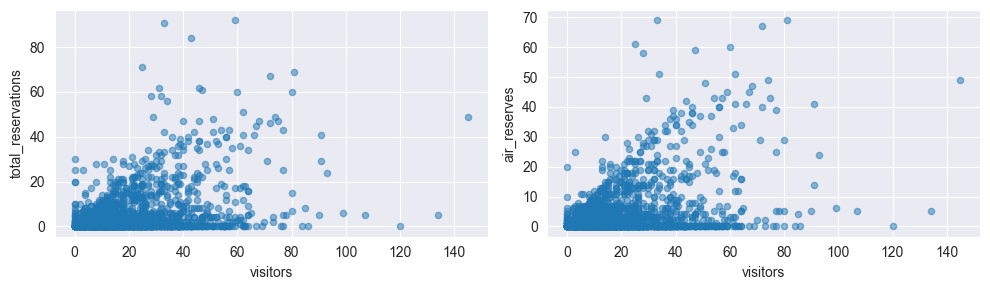

In [70]:
all_merged = add_reservation_impossibility(all_merged, air_reserve_df, hpg_reserve_df)
sample = all_merged.sample(5000, random_state=RANDOM_SEED)
sample = sample[sample[RES_IMPOSSIBILITY_COL] == 0]
pairs = [
    (VISITORS_COL, TOTAL_RES_COL),
    (VISITORS_COL, RESERVE_AIR_COL),
]
plot_pairs_rel(pairs, sample)

Overall, the correlation between visitors and reservations is weak. The graph shows that the correlation is weak due to restaurants with 0 reservations, but overall there is a trend.

### Reservations greater than visitors

#### Count of anomalies

The case when we compare only air_reservations and visitors:

In [71]:
len(all_merged[all_merged[RESERVE_AIR_COL] > all_merged[VISITORS_COL]])

3332

The case when we compare the maximum of (air_reservations, hpg_reservations) and visitors:

In [72]:
max_res = all_merged[[RESERVE_AIR_COL, RESERVE_HPG_COL]].max(axis=1)
len(all_merged[max_res > all_merged[VISITORS_COL]])

4137

The case when we compare the sum of (air_reservations, hpg_reservations) and visitors:

In [73]:
res_gt_vis = all_merged[all_merged[TOTAL_RES_COL] > all_merged[VISITORS_COL]]
len(res_gt_vis)

5679

#### Percentage of anomalies

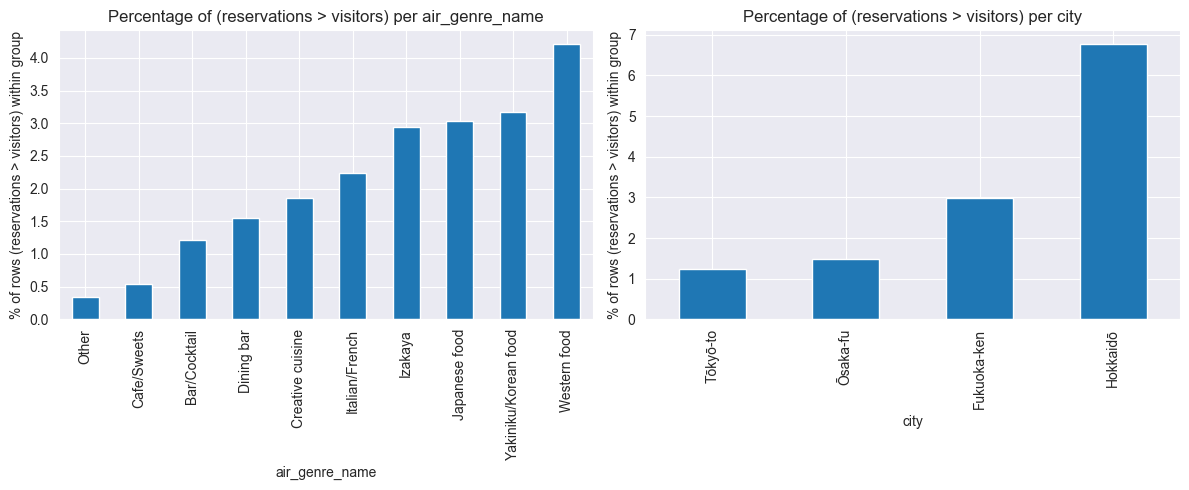

In [74]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for group, axes in zip([AIR_GENRE_COL, CITY_COL], ax):
    size_ratio = get_group_size_ratio(res_gt_vis, all_merged, group)
    plot_over_reservation(size_ratio.sort_values(), axes, group, "bar")

plt.tight_layout()
plt.show()

In [75]:
air_hpg_genre_merged = air_hpg_genre_merged.rename(columns={"city_x": CITY_COL})

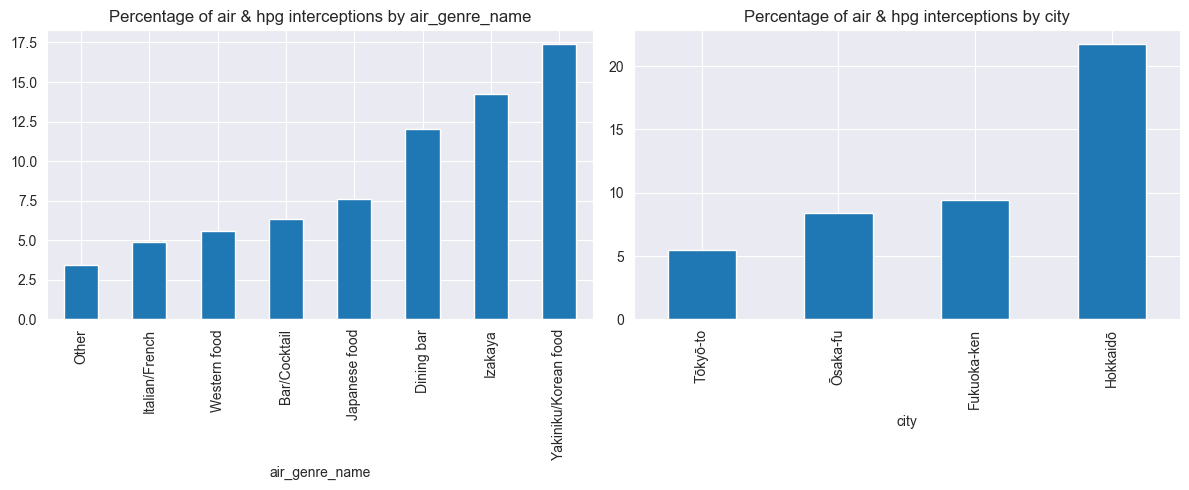

In [76]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for group, axes in zip([AIR_GENRE_COL, CITY_COL], ax):
    size_ratio = get_group_size_ratio(air_hpg_genre_merged, air_store_df, group)
    plot_hpg_interc_pct(size_ratio.dropna().sort_values(), axes, group, "bar")

plt.tight_layout()
plt.show()

In [77]:
dates_with_holidays = add_holiday_columns(date_info_df, CALENDAR_DATE_COL)
dates_occurred_df, _ = split_reserve_by_date(
    dates_with_holidays, min_sample_date, CALENDAR_DATE_COL
)
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

dates_occurred_df[DAY_OF_WEEK_COL] = pd.Categorical(
    dates_occurred_df[DAY_OF_WEEK_COL],
    categories=days_order,
    ordered=True
)

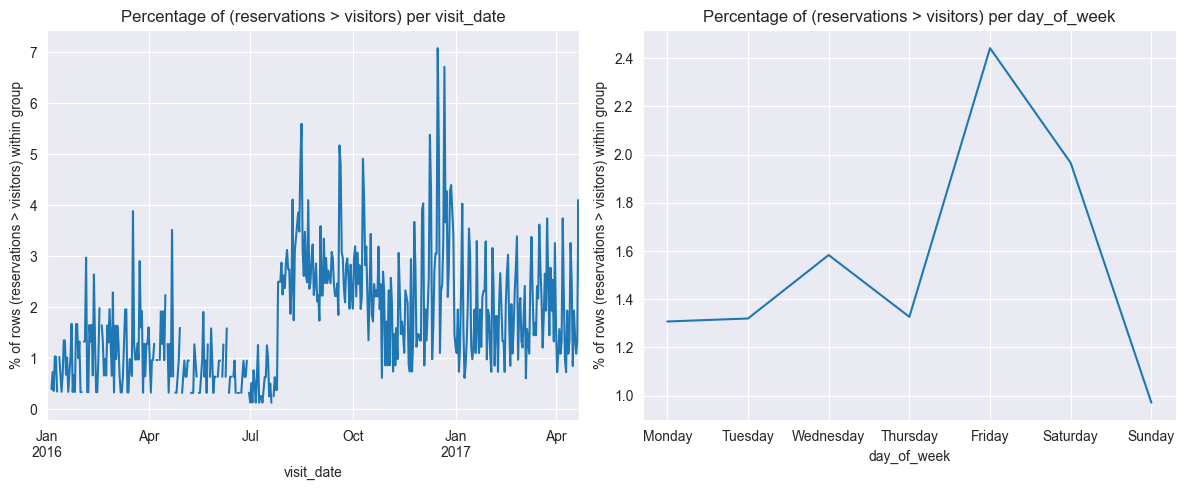

In [78]:
size_per_day = get_group_size_ratio(res_gt_vis, all_merged, VISIT_DATE_COL)
size_per_day_df = size_per_day.to_frame().merge(
    dates_occurred_df, left_index=True, right_on=CALENDAR_DATE_COL
)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
plot_over_reservation(size_per_day, ax[0], VISIT_DATE_COL, "line")

dow_mean = size_per_day_df.groupby(DAY_OF_WEEK_COL, observed=False)[0].median()
plot_over_reservation(dow_mean, ax[1], DAY_OF_WEEK_COL, "line")

plt.tight_layout()
plt.show()

During the gap period, after filling, many similar anomalies appeared.

In [79]:
size_per_day_df.groupby(HOLIDAY_COL)[0].median().rename("% of anomalies")

holiday_flg
0    1.568154
1    1.465201
Name: % of anomalies, dtype: float64

#### Repeated reservations

In [80]:
repeated_reservations = air_reserve_df.merge(
    hpg_res_air_merged,
    on=[
        AIR_RESTAURANT_ID_COL,
        RESERVE_DATETIME_COL,
        RESERVE_VISITORS_COL,
        VISIT_DATETIME_COL,
        VISIT_DATE_COL
    ]
)
repeated_reservations.head()

,air_store_id,visit_datetime,reserve_datetime,reserve_visitors,visit_date,hpg_store_id
0,air_6b15edd1b4fbb96a,2016-01-02 17:00:00,2016-01-01 22:00:00,3,2016-01-02,hpg_babe2c3d962d7bb6
1,air_6b15edd1b4fbb96a,2016-01-02 18:00:00,2016-01-01 12:00:00,3,2016-01-02,hpg_babe2c3d962d7bb6
2,air_6b15edd1b4fbb96a,2016-01-02 18:00:00,2016-01-01 12:00:00,3,2016-01-02,hpg_babe2c3d962d7bb6
3,air_db80363d35f10926,2016-01-03 18:00:00,2016-01-02 20:00:00,6,2016-01-03,hpg_878cc70b1abc76f7
4,air_2cee51fa6fdf6c0d,2016-01-05 20:00:00,2016-01-04 22:00:00,2,2016-01-05,hpg_113fd6e4fa77800f


In [81]:
air_hpg_merged = air_reserve_df.merge(
    store_id_rel_df,
    on=AIR_RESTAURANT_ID_COL
)

In [82]:
rep_size = len(repeated_reservations)

print("Count of reservations that are both in air and hpg:", rep_size)
print("The percentage of all samples in hpg that have are related to air:", rep_size / len(hpg_res_air_merged))
print("The percentage of all samples in air that have are related to hpg:", rep_size / len(air_hpg_merged))

Count of reservations that are both in air and hpg: 4438
The percentage of all samples in hpg that have are related to air: 0.15983001404544964
The percentage of all samples in air that have are related to hpg: 0.12238032208250607


So, 16% of all bookings in hpg and 12% of all bookings in air are duplicated (that have a relation). It's not that serious (at least not a 50%).

In [83]:
rep_by_day = repeated_reservations.groupby(VISIT_DATE_COL).mean(RESERVE_VISITORS_COL)

In [84]:
print("Count of days with repetitions:", len(rep_by_day))

Count of days with repetitions: 338


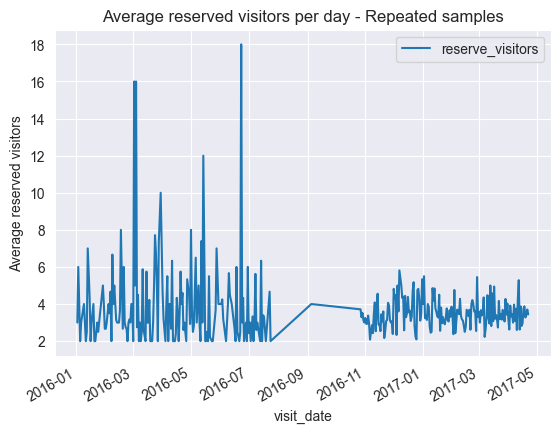

In [85]:
rep_by_day.plot()
plt.ylabel("Average reserved visitors")
plt.title("Average reserved visitors per day - Repeated samples")
plt.show()

Average time about the same (except for the period with gaps)

In [86]:
rep_res_sum = repeated_reservations.groupby(
    [AIR_RESTAURANT_ID_COL, VISIT_DATE_COL]
).sum(RESERVE_VISITORS_COL)
all_with_rep = all_merged.merge(
    rep_res_sum,
    left_on=[AIR_RESTAURANT_ID_COL, VISIT_DATE_COL],
    right_index=True,
    how="left"
).fillna(0)
all_with_rep[TOTAL_RES_COL] = all_with_rep[TOTAL_RES_COL] - all_with_rep[RESERVE_VISITORS_COL]

In [87]:
res_gt_vis = all_with_rep[all_with_rep[TOTAL_RES_COL] > all_with_rep[VISITORS_COL]]
len(res_gt_vis)

5185

Of all the anomalies, approximately 500 were related to duplicates. The rest were of unknown origin and may simply have been due to visitors not showing up.

In [88]:
all_with_rep[[VISITORS_COL, TOTAL_RES_COL]].corr()

,visitors,total_reservations
visitors,1.000000,0.218751
total_reservations,0.218751,1.000000


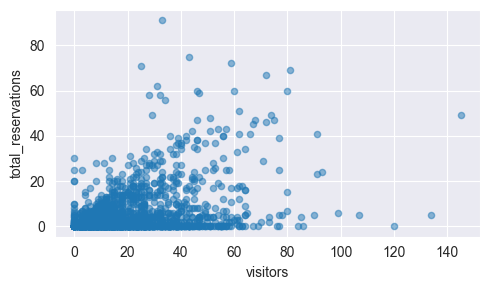

In [89]:
all_with_rep = add_reservation_impossibility(all_with_rep, air_reserve_df, hpg_reserve_df)
sample = all_with_rep.sample(5000, random_state=RANDOM_SEED)
sample = sample[sample[RES_IMPOSSIBILITY_COL] == 0]
pairs = [(VISITORS_COL, TOTAL_RES_COL)]
plot_pairs_rel(pairs, sample)

The graph shows almost no differences, as 4000 duplicate samples represent approximately 1 percent of all samples. This means that the linear relationship remains, but there are still outliers in both directions (few bookings lead to many visitors, and vice versa).

As a result, situations where the number of reservations exceeds the number of visitors occur more frequently in certain genres, cities, and on certain days of the week. There is no clear dependency with holidays.

Duplicate reservations are not the primary cause of the anomalies, as only 500 of the 5800 anomalies disappeared after the feature revision. The causes for the remaining cases can be varied, and it's difficult to determine when this might occur.

Previously, I was taking into account artificially created dates before openings (when there were no samples yet, but reservations were). This resulted in approximately 4000 additional anomalies.

It might be worth flagging restaurants that tend to overbook (possibly indicating the day of the week).

### 0 reservations - a lot of visitors

In [90]:
diff_median = (all_with_rep[VISITORS_COL] - all_with_rep[TOTAL_RES_COL])[
    all_with_rep[TOTAL_RES_COL] != 0
].median()
print("Median difference between visitors and bookings (excluding zero bookings)", diff_median)

Median difference between visitors and bookings (excluding zero bookings) 10.0


Next, we'll assume that the median is 10. Let's consider cases where we have 0 bookings and more than 10 visitors.

In [91]:
nores_v_gt_10 = (all_with_rep[VISITORS_COL] > 10) & (all_with_rep[TOTAL_RES_COL] == 0)
res_possible = ~(all_with_rep[RES_IMPOSSIBILITY_COL].astype(bool))
gap_mask = all_with_rep[VISIT_DATE_COL].isin(EMPTY_DATES_RANGE)
nores_v_gt_10 &= res_possible

In [92]:
nores_df = all_with_rep[nores_v_gt_10]
event_size = len(nores_df)
gap_event_size = len(nores_df.loc[gap_mask])
res_possible_size = len(all_with_rep[res_possible])
hpg_event_size = len(nores_df.loc[all_with_rep[HPG_RESTAURANT_ID_COL] != 0])

print("Count of situations:", event_size)
print("Count of situations where restaurant have hpg reservation possibility:", hpg_event_size)
print("Count of situations during gap period:", gap_event_size)
print("Percentage of situations:", round(event_size / res_possible_size, 2))

Count of situations: 38415
Count of situations where restaurant have hpg reservation possibility: 17629
Count of situations during gap period: 8869
Percentage of situations: 0.32


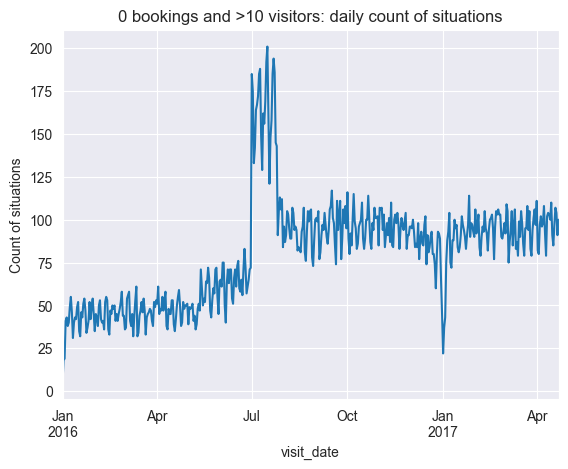

In [93]:
nores_df.groupby(VISIT_DATE_COL).size().plot()
plt.ylabel("Count of situations")
plt.title("0 bookings and >10 visitors: daily count of situations")
plt.show()

Although official sources indicate that maintenance work on the air reservation system has been ongoing since August, there are also many cases of zeros in early July. This situation may be due to the fact that many new restaurants opened during this period and reservations haven't been taken yet, for example. But I need to look into the details.

In [101]:
month_after_opening = (
    nores_df[VISIT_DATE_COL] >
    nores_df[OPEN_DATE_COL] + pd.DateOffset(months=1)
)

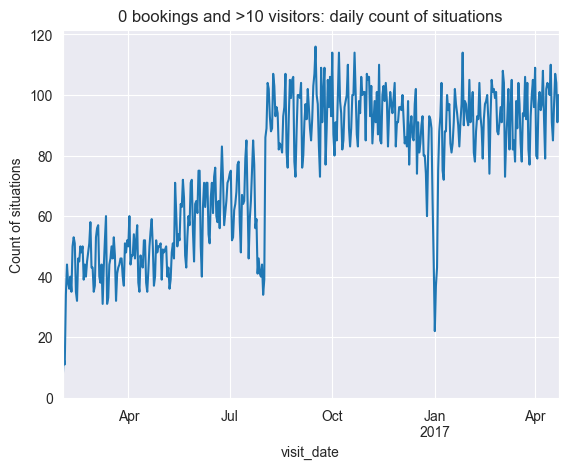

In [102]:
nores_df[month_after_opening].groupby(VISIT_DATE_COL).size().plot()
plt.ylabel("Count of situations")
plt.title("0 bookings and >10 visitors: daily count of situations")
plt.show()

Most of the anomalies in July have disappeared, if we don't count the restaurants that opened recently.

### July period

In [139]:
july_info = all_merged[all_merged[VISIT_DATE_COL].between("2016-07-01", "2016-07-25")]
june_info = all_merged[all_merged[VISIT_DATE_COL].between("2016-06-01", "2016-06-30")]

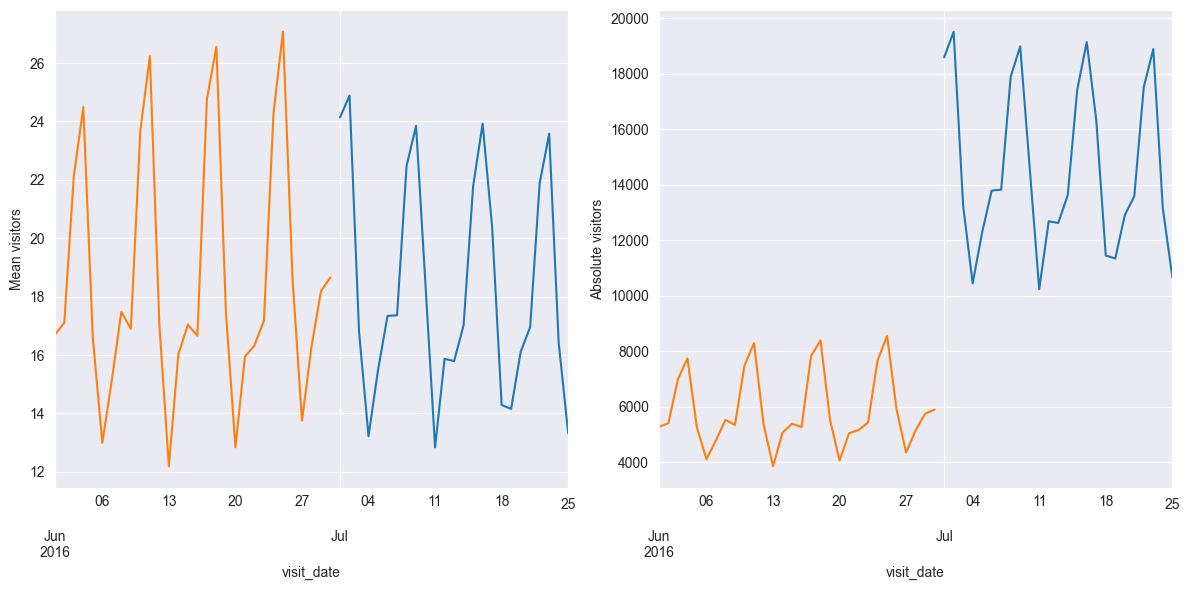

In [160]:
fig, ax = plt.subplots(*(1, 2), figsize=(12, 6))

ax[0].set_ylabel("Mean visitors")
july_info.groupby(VISIT_DATE_COL)[VISITORS_COL].mean().plot(ax=ax[0])
june_info.groupby(VISIT_DATE_COL)[VISITORS_COL].mean().plot(ax=ax[0])

ax[1].set_ylabel("Absolute visitors")
july_info.groupby(VISIT_DATE_COL)[VISITORS_COL].sum().plot(ax=ax[1])
june_info.groupby(VISIT_DATE_COL)[VISITORS_COL].sum().plot(ax=ax[1])

plt.tight_layout()
plt.show()

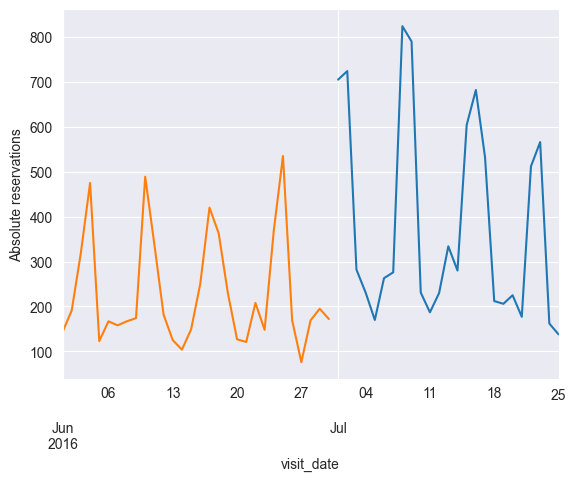

In [161]:
july_info.groupby(VISIT_DATE_COL)[TOTAL_RES_COL].sum().plot()
june_info.groupby(VISIT_DATE_COL)[TOTAL_RES_COL].sum().plot()
plt.ylabel("Absolute reservations")
plt.show()

In [173]:
june_res_pos = june_info[june_info[RES_IMPOSSIBILITY_COL] == 0]
july_res_pos = july_info[july_info[RES_IMPOSSIBILITY_COL] == 0]

In [175]:
print_period_problematic_rest(
    "June",
    len(june_res_pos[AIR_RESTAURANT_ID_COL].unique()),
    get_all_zero_reservations(june_res_pos).sum()
)
print()
print_period_problematic_rest(
    "July",
    len(july_res_pos[AIR_RESTAURANT_ID_COL].unique()),
    get_all_zero_reservations(july_res_pos).sum()
)

Period: June
[Restaurants with reservation possibility are taken into account]
Count of restaurants: 129
Count of restaurants with all 0 reservations: 66

Period: July
[Restaurants with reservation possibility are taken into account]
Count of restaurants: 314
Count of restaurants with all 0 reservations: 160


Although the absolute number of visitors increased significantly in July due to the increase in the number of restaurants, the absolute number of reservations changed less significantly. Half of the newly added restaurants initially had no reservations (zero reservations overall), although they continued to have reservations throughout the period. This further confirms the need to review the reservation_impossibility feature.

Otherwise, no differences were observed during this period. The seasonality was the same, and the average was slightly lower.